# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Bintang Qaulan Tsaqiila
- **Email:** bintangqaulan@gmail.com
- **ID Dicoding:** CDCC123D6Y0309

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

#### Pertanyaan Bisnis:

1.  Bagaimana kondisi cuaca ekstrem (weathersit = 3 atau 4) memengaruhi penurunan rata-rata jumlah penyewaan sepeda harian (`cnt`) pada tahun 2011 dan 2012 di Washington D.C.?

2.  Pada musim apa terjadi puncak permintaan penyewaan sepeda tertinggi, dan bagaimana proporsi pengguna `casual` dan `registered` pada periode tersebut?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
# agar tidak bolak-balik upload dataset ke runtime
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/Coding camp/bike sharing"

In [4]:
# overview tabel day
day_df = pd.read_csv(path + "/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
# overview tabel hour
hour_df = pd.read_csv(path + "/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Tabel day menjelaskan banyaknya pemesanan sepeda per hari
- Tabel hour lebih merinci jumlah pemesanan per jamnya

### Assessing Data

**Langkah-langkah:**
- Mengidentifikasi data duplikat
- Mengidentifikasi missing value
- Memeriksa tipe data
- Melihat ringkasan statistik

#### Mengidentifikasi data duplikat

In [6]:
print(f"Jumlah duplikasi pada day_df: {day_df.duplicated().sum()}")

Jumlah duplikasi pada day_df: 0


#### Mengidentifikasi Missing Value

In [7]:
print("Missing value dalam day_df:")
display(day_df.isnull().sum())

Missing value dalam day_df:


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [8]:
print("Missing values dalam hour_df:")
display(hour_df.isnull().sum())

Missing values dalam hour_df:


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


#### Memeriksa Tipe Data

In [9]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [10]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


#### Ringkasan Statistik `day_df`

In [11]:
display(day_df.describe())

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


#### Ringkasan Statistik `hour_df`

In [12]:
display(hour_df.describe())

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Data tidak terdapat missing value dan duplikat
- Kolom yang perlu dihapus:
  1.   "instant", karena hanya berisi index
- tipe kolom "dteday" perlu diganti ke tipe datetime untuk memudahkan analisis berbasis waktu


### Cleaning Data

#### Menghapus kolom yang tidak perlu

In [13]:
drop_columns = ['instant']
day_df.drop(columns=drop_columns, inplace=True)
hour_df.drop(columns=drop_columns, inplace=True)

In [14]:
hour_df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [15]:
day_df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Mengubah tipe kolom "dteday" ke datetime

In [16]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print(day_df['dteday'].dtype)
print(hour_df['dteday'].dtype)

datetime64[ns]
datetime64[ns]


## Exploratory Data Analysis (EDA)

In [17]:
# penggunaan sepeda per musim
pivot_season = day_df.pivot_table(
    index='season',
    values='cnt',
    aggfunc='mean',
    observed=True
)
pivot_season.head()

,cnt
season,
1,2604.132597
2,4992.331522
3,5644.303191
4,4728.162921


In [18]:
#penggunaan sepeda pada cuaca tertentu di tahun 2011
pivot_weathersit_2011 = day_df[day_df['yr'] == 0].pivot_table(
    index='weathersit',
    values='cnt',
    aggfunc='mean'
)
pivot_weathersit_2011.head()

,cnt
weathersit,
1,3694.986726
2,3088.096774
3,1674.133333


In [19]:
#penggunaan sepeda pada cuaca tertentu di tahun 2012
pivot_weathersit_2012 = day_df[day_df['yr'] == 1].pivot_table(
    index='weathersit',
    values='cnt',
    aggfunc='mean'
)
pivot_weathersit_2012.head()

,cnt
weathersit,
1,6003.734177
2,4991.333333
3,2126.166667


In [20]:
# distribusi penggunaan sepeda bulanan
distribution_monthly = day_df['cnt'].describe()
distribution_monthly.head(10)

,cnt
count,731.000000
mean,4504.348837
std,1937.211452
min,22.000000
25%,3152.000000
50%,4548.000000
75%,5956.000000
max,8714.000000


In [21]:
# hubungan cuaca terhadap penggunaan sepeda
corr_weather_cnt = day_df[['weathersit', 'cnt']].corr()
corr_weather_cnt.head()

,weathersit,cnt
weathersit,1.000000,-0.297391
cnt,-0.297391,1.000000


In [22]:
# perbandingan registered dan casual tiap bulan
pivot_month_registered = day_df.pivot_table(
    index='mnth',
    values=['registered', 'casual'],
    aggfunc='mean'
)
pivot_month_registered.head(12)

,casual,registered
mnth,,
1,194.225806,1982.112903
2,262.508772,2392.789474
3,716.838710,2975.419355
4,1013.366667,3471.533333
5,1214.274194,4135.500000
6,1231.766667,4540.600000
7,1260.596774,4303.080645
8,1161.919355,4502.500000
9,1172.050000,4594.466667


In [23]:
# perbandingan registered dan casual per musim
pivot_season_registered = day_df.pivot_table(
    index='season',
    values=['registered', 'casual'],
    aggfunc='mean'
)
pivot_season_registered.head()

,casual,registered
season,,
1,334.928177,2269.204420
2,1106.097826,3886.233696
3,1202.611702,4441.691489
4,729.112360,3999.050562


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana kondisi cuaca hujan atau salju memengaruhi penurunan rata-rata jumlah penyewaan sepeda harian pada tahun 2011 dan 2012?

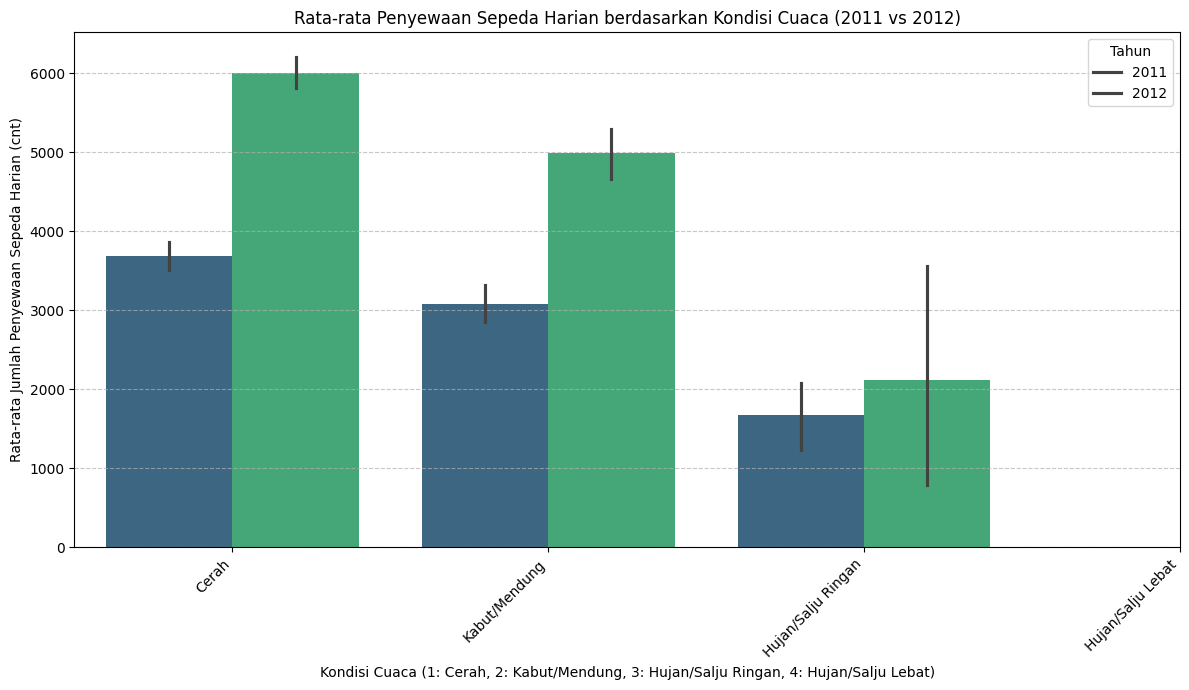

In [24]:
plt.figure(figsize=(12, 7))
sns.barplot(x='weathersit', y='cnt', hue='yr', data=day_df, estimator=np.mean, palette='viridis')
plt.title('Rata-rata Penyewaan Sepeda Harian berdasarkan Kondisi Cuaca (2011 vs 2012)')
plt.xlabel('Kondisi Cuaca (1: Cerah, 2: Kabut/Mendung, 3: Hujan/Salju Ringan, 4: Hujan/Salju Lebat)')
plt.ylabel('Rata-rata Jumlah Penyewaan Sepeda Harian (cnt)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Cerah', 'Kabut/Mendung', 'Hujan/Salju Ringan', 'Hujan/Salju Lebat'], rotation=45, ha='right')
plt.legend(title='Tahun', labels=['2011', '2012'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Grafik menunjukkan bahwa jumlah penyewaan sepeda harian paling tinggi adalah ketika cuaca cerah, dan ketika hujan atau salju lebat, tidak ada penyewaan sama sekali. Perkembangan pelanggan per tahun paling tinggi juga terjadi ketika cuaca cerah. Dari observasi tersebut, strategi yang tepat adalah meningkatkan penjualan ketika cuaca cerah hingga mendung agar bisa mengantisipasi penurunan penjualan di cuaca hujan atau salju.

### Pertanyaan 2: Pada musim apa terjadi puncak permintaan penyewaan sepeda tertinggi, dan bagaimana proporsi pengguna `casual` dan `registered` pada periode tersebut?

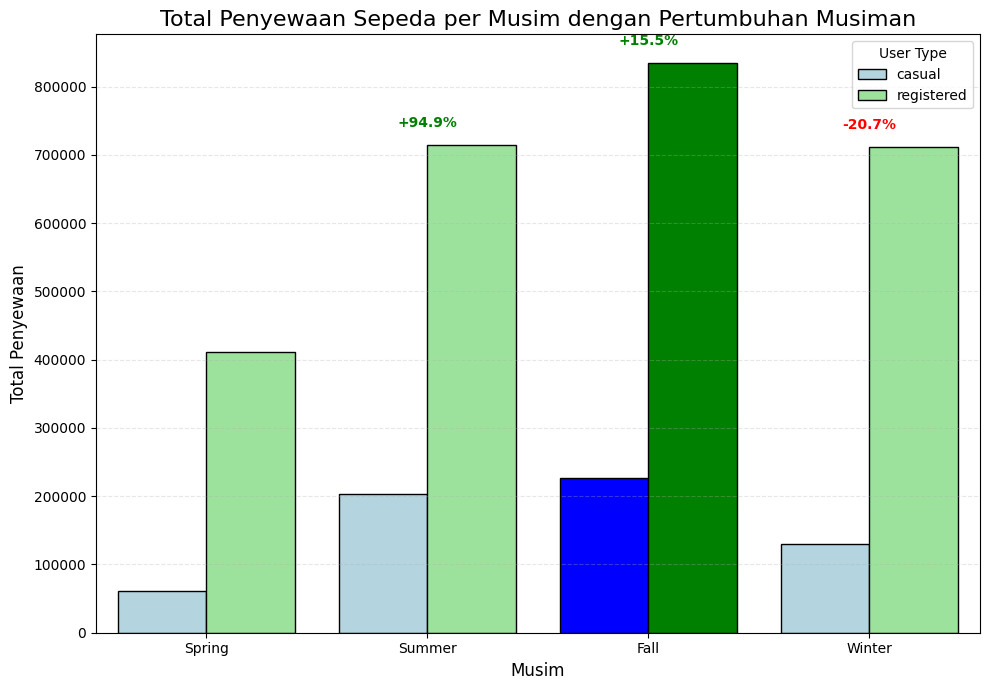

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Memetakan nomor musim ke nama dan mengurutkan dengan benar
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_names = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_name'] = day_df['season'].map(season_names)

# Mengagregasi data berdasarkan musim
seasonal_agg = day_df.groupby('season_name', as_index=False)[['casual', 'registered', 'cnt']].sum()
seasonal_agg['season_name'] = pd.Categorical(seasonal_agg['season_name'], categories=season_order, ordered=True)
seasonal_agg = seasonal_agg.sort_values('season_name').reset_index(drop=True)

# Menghitung persentase perubahan dibandingkan musim sebelumnya
seasonal_agg['pct_change'] = seasonal_agg['cnt'].pct_change() * 100

# Menemukan musim dengan jumlah casual dan registered tertinggi
max_casual_season_name = seasonal_agg.loc[seasonal_agg['casual'].idxmax(), 'season_name']
max_registered_season_name = seasonal_agg.loc[seasonal_agg['registered'].idxmax(), 'season_name']

# Membuat plot
fig, ax = plt.subplots(figsize=(10, 7))
seasonal_melted = seasonal_agg.melt(id_vars=['season_name', 'pct_change'], value_vars=['casual', 'registered'], var_name='User Type', value_name='Count')

# Mendefinisikan warna dasar untuk palet
base_palette = {'casual': 'lightblue', 'registered': 'lightgreen'}
hue_order = ['casual', 'registered']

# Plot bar chart dengan warna dasar dan edgecolor hitam untuk semua bar
sns.barplot(
    x='season_name',
    y='Count',
    hue='User Type',
    data=seasonal_melted,
    ax=ax,
    palette=base_palette,
    hue_order=hue_order,
    dodge=True,
    edgecolor='black' # Terapkan edgecolor hitam ke semua bar di awal
)

# Iterasi melalui bar (patches) untuk menyesuaikan warna untuk musim-musim dengan nilai maksimum
# Lakukan perulangan melalui setiap kontainer bar (satu untuk setiap 'User Type' dalam hue_order)
for container_idx, container in enumerate(ax.containers):
    current_user_type = hue_order[container_idx]
    for patch_idx, patch in enumerate(container.patches):
        current_season_name = season_order[patch_idx]

        # Terapkan warna lebih tua untuk nilai maksimum
        if current_user_type == 'casual' and current_season_name == max_casual_season_name:
            patch.set_facecolor('blue')
        elif current_user_type == 'registered' and current_season_name == max_registered_season_name:
            patch.set_facecolor('green')

ax.set_title('Total Penyewaan Sepeda per Musim dengan Pertumbuhan Musiman', fontsize=16)
ax.set_xlabel('Musim', fontsize=12)
ax.set_ylabel('Total Penyewaan', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Menambahkan label persentase perubahan di atas setiap kelompok musim
for i, row in seasonal_agg.iterrows():
    if not np.isnan(row['pct_change']):
        label = f"{row['pct_change']:+.1f}%"
        # Dapatkan 'Count' maksimum untuk musim saat ini dari seasonal_melted
        max_val_for_season = seasonal_melted[seasonal_melted['season_name'] == row['season_name']]['Count'].max()
        ax.text(i, max_val_for_season + (seasonal_agg['cnt'].max() * 0.02), label,
                ha='center', va='bottom', fontweight='bold', color='red' if row['pct_change'] < 0 else 'green', fontsize=10)

plt.tight_layout()
plt.show()

day_df.drop(columns=['season_name'], inplace=True)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Ketika cuaca buruk, penduduk akan jarang keluar yang berakibat pada menurunnya penyewaan sepeda
- **Conclusion pertanyaan 2:** Penjualan tertinggi terjadi pada musim gugur yang didominasi oleh pengguna terdaftar

**Rekomendasi Action Item:**
- Tingkatkan penjualan ketika cuaca cerah dan mendung, lakukan penghematan operasional ketika cuaca buruk
- Lihat faktor apa saja yang mempengaruhi angka penjualan di setiap musim, tingkatkan pemasaran di musim-musim lainnya
- Tambah benefit yang ditawarkan untuk pengguna yang terdaftar agar semakin banyak yang mendaftar